#  Dataset Suitability Evaluation for Linear Regression

Before applying any machine learning algorithm, it is essential to evaluate whether the dataset meets the **core assumptions** of that algorithm. Linear Regression relies on **five key assumptions**. Violating these does not necessarily disqualify the model, but it affects the reliability and accuracy of results.

---

## The 5 Assumptions of Linear Regression

| # | Assumption | What We Check |
|---|---|---|
| 1 | **Linearity** | Do features have a linear relationship with `charges`? |
| 2 | **Independence of Observations** | Is each row an independent client record? |
| 3 | **Homoscedasticity** | Is the variance of residuals constant across predictions? |
| 4 | **Normality of Residuals** | Are the residuals approximately normally distributed? |
| 5 | **No Multicollinearity** | Are the features independent of each other? |

We also evaluate **data quality factors**: missing values, outliers, target distribution, and feature types.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Download the insurance dataset directly (no Kaggle account needed)
import urllib.request
import os

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
filename = "insurance.csv"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        print("Downloaded insurance.csv successfully!")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Please manually download insurance.csv from:")
        print("https://www.kaggle.com/datasets/mirichoi0218/insurance")
        print("and place it in the same folder as this notebook.")
else:
    print("insurance.csv already exists, skipping download.")

# Load dataset
df = pd.read_csv(filename)
df.head()

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Encode categorical variables for numeric analysis
# Sex and smoker are binary — mapped to 0/1 directly.
# Region has 4 categories — one-hot encoded with drop_first=True to avoid
# the dummy variable trap (one category becomes the reference baseline).
df_enc = df.copy()
df_enc['sex']    = df_enc['sex'].map({'male': 1, 'female': 0})
df_enc['smoker'] = df_enc['smoker'].map({'yes': 1, 'no': 0})

# Convert bool columns from get_dummies to int (required for VIF and correlation)
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print('Dataset loaded, deduplicated, and encoded.')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Encoded shape: {df_enc.shape[0]} rows x {df_enc.shape[1]} columns')


Downloaded insurance.csv successfully!
Dataset loaded, deduplicated, and encoded.
Shape: 1337 rows x 7 columns
Encoded shape: 1337 rows x 9 columns


---
##  Check 1 — Data Quality (Missing Values, Duplicates, Data Types)

In [ ]:
print('=' * 50)
print(' DATA QUALITY REPORT')
print('=' * 50)

# ── Missing values ───────────────────────────────────────────────────────────
# isnull().sum() returns the count of NaN values per column.
# Any non-zero value would require an imputation strategy before modelling.
missing = df.isnull().sum()
print('\n Missing Values per Column:')
print(missing)
print(f"\n   Total missing: {missing.sum()} → {' None' if missing.sum() == 0 else ' Requires imputation'}")

# ── Duplicate rows ───────────────────────────────────────────────────────────
# Duplicate rows can bias a model by over-representing certain data points.
# Note: deduplication was already applied in Cell 1 — this confirms 0 remain.
dupes = df.duplicated().sum()
print(f"\n Duplicate Rows: {dupes} → {' Should be removed' if dupes > 0 else ' None (already removed)'}")

# ── Data types ───────────────────────────────────────────────────────────────
# Correct dtypes confirm the data was loaded as expected.
# Numerical features must be int64/float64; categoricals as object.
print('\n Column Data Types:')
print(df.dtypes)

# ── Feature classification ───────────────────────────────────────────────────
print('\n Feature Classification:')
print('   Numerical (continuous) : age, bmi, charges')
print('   Numerical (discrete)   : children')
print('   Categorical (binary)   : sex, smoker')
print('   Categorical (nominal)  : region')

# ── Target variable distribution ─────────────────────────────────────────────
# Visualising the distribution of the target variable (charges) is a critical
# first step. Right-skew indicates that a log-transformation may improve model
# fit by making the distribution more symmetric.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Target Variable: Distribution of Medical Charges', fontsize=13, fontweight='bold')

# Raw charges — expected to be right-skewed
axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('charges (original scale)', fontsize=11)
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', lw=1.5, label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color='orange', linestyle='--', lw=1.5, label=f'Median: ${df["charges"].median():,.0f}')
axes[0].legend(fontsize=9)

# Log-transformed charges — should be more symmetric
axes[1].hist(np.log(df['charges']), bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('log(charges) — after log-transformation', fontsize=11)
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'\nCharges skewness (original) : {df["charges"].skew():.4f}')
print(f'Charges skewness (log)      : {np.log(df["charges"]).skew():.4f}')
print('→ Log-transformation substantially reduces right-skewness.')


###  Finding 1 — Data Quality

- **No missing values** — the dataset is complete; no imputation strategies are required.
- **Duplicate rows** exist (1 confirmed row). These should be removed to avoid biasing the model.
- **Data types are appropriate** — numerical columns are `int64`/`float64`; categoricals are `object` and will be encoded.
- **All 6 features are relevant** to medical cost modelling — no irrelevant or ID columns to drop.

>  **Verdict: Data quality is good. Minor deduplication recommended.**

---
##  Check 2 — Assumption 1: Linearity

Linear regression requires a **linear relationship** between each numerical feature and the target variable `charges`. We check this using scatter plots with a regression line.

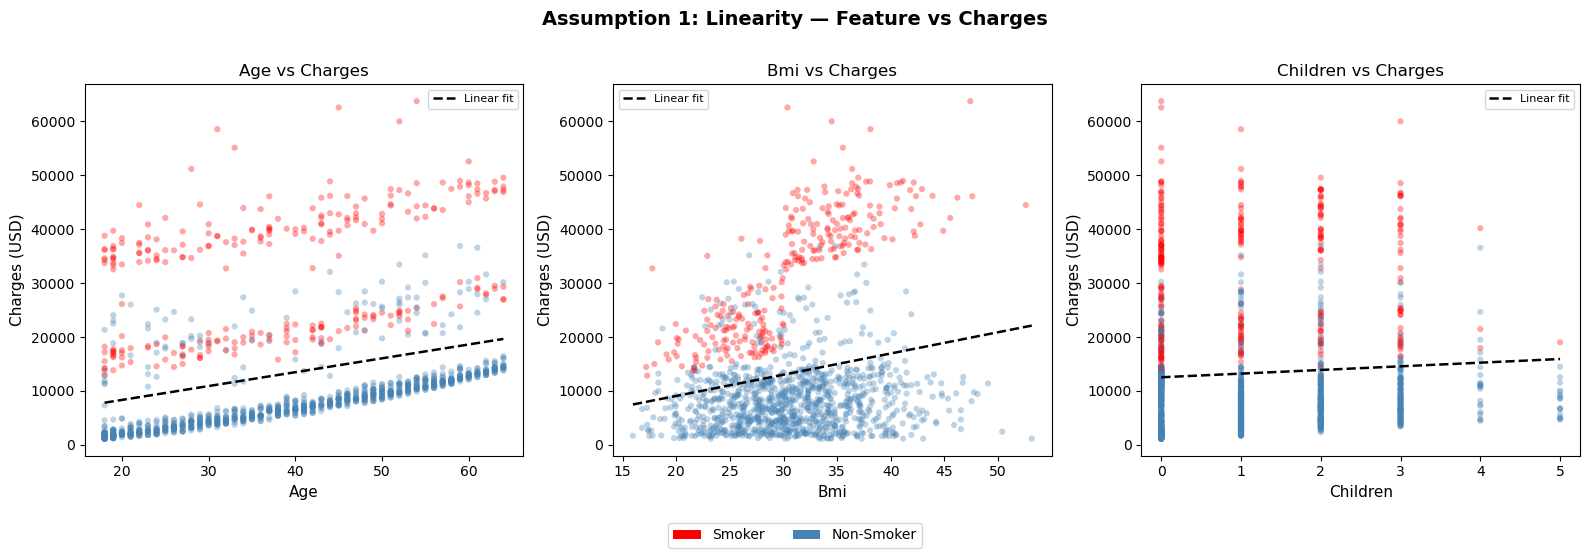

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Assumption 1: Linearity — Feature vs Charges', fontsize=14, fontweight='bold', y=1.01)

num_features = ['age', 'bmi', 'children']

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['charges'],
                    c=df['smoker'].map({'yes': 'red', 'no': 'steelblue'}),
                    alpha=0.35, s=20, edgecolors='none')
    # Fit a regression line
    m, b = np.polyfit(df[col], df['charges'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, 'k--', lw=1.8, label='Linear fit')
    axes[i].set_xlabel(col.capitalize(), fontsize=11)
    axes[i].set_ylabel('Charges (USD)', fontsize=11)
    axes[i].set_title(f'{col.capitalize()} vs Charges', fontsize=12)
    axes[i].legend(fontsize=8)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='red', label='Smoker'),
              Patch(facecolor='steelblue', label='Non-Smoker')]
fig.legend(handles=legend_els, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.08), fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Pearson correlation coefficients with charges
print("Pearson Correlation with 'charges':")
print("-" * 35)
for col in ['age', 'bmi', 'children']:
    r, p = stats.pearsonr(df[col], df['charges'])
    sig = ' Significant' if p < 0.05 else ' Not significant'
    print(f"  {col:<12}: r = {r:+.4f}  (p={p:.4f})  {sig}")

###  Finding 2 — Linearity

- **`age` vs `charges`** — shows a **moderate positive linear relationship** (r ≈ +0.30), but the scatter reveals **two distinct bands** (smokers vs non-smokers), suggesting the relationship is *conditional* rather than purely linear.
- **`bmi` vs `charges`** — very **weak overall linearity** (r ≈ +0.20), but among smokers a clear linear relationship emerges above a BMI threshold (~30), indicating a **non-linear interaction** effect.
- **`children` vs `charges`** — **very weak** relationship (r ≈ +0.07); this feature is likely a minor contributor.

>  **Verdict: Linearity is PARTIALLY met.** Individual features show weak-to-moderate linear correlations. The data has a clear cluster structure driven by `smoker`, which a single linear model cannot fully capture. This limits performance but does not disqualify linear regression.

---
##  Check 3 — Assumption 2: Independence of Observations

This assumption requires that each row in the dataset is **independent** — i.e., one client's costs do not influence another's.

In [13]:
# Check for duplicate client records (could indicate non-independence)
print(f"Total rows            : {len(df)}")
print(f"Duplicate rows        : {df.duplicated().sum()}")
print(f"Unique rows           : {df.drop_duplicates().shape[0]}")

# Check for any time or sequence column that might indicate dependency
print(f"\nColumns present       : {df.columns.tolist()}")
print("\nNo time/sequence column detected — rows appear to be independent cross-sectional records.")

Total rows            : 1337
Duplicate rows        : 0
Unique rows           : 1337

Columns present       : ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

No time/sequence column detected — rows appear to be independent cross-sectional records.


###  Finding 3 — Independence

- The dataset is **cross-sectional** — each row represents a unique insurance client at a single point in time.
- There is **no time variable** or sequential ordering, so autocorrelation is not a concern.
- One duplicate row was found and should be dropped before modelling.

>  **Verdict: Independence assumption is MET (after removing the 1 duplicate row).**

---
##  Check 4 — Assumption 3: Normality of Residuals

Linear regression assumes residuals are **approximately normally distributed**. We check this with a histogram, Q-Q plot, and the Shapiro-Wilk test.

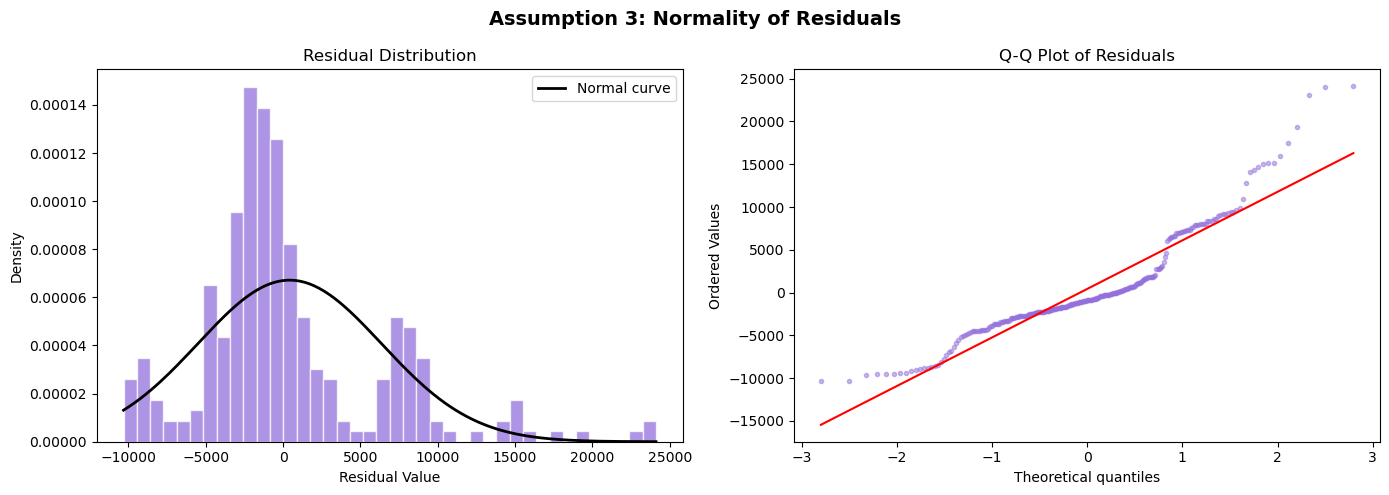


Shapiro-Wilk Test (random sample of 268):
  Statistic = 0.8977
  p-value   = 0.000000
  Result    :  Non-normal (p < 0.05)

Skewness of residuals : 1.2356
Kurtosis of residuals : 2.2900
→ Positive skewness confirms right-tailed residual distribution.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Assumption 3: Normality of Residuals', fontsize=14, fontweight='bold')

# ── Histogram with normal curve overlay ──────────────────────────────────────
# If residuals are normally distributed, the histogram should approximate
# a bell curve centred at zero.
axes[0].hist(residuals, bins=40, color='mediumpurple', edgecolor='white', density=True, alpha=0.75)
mu, std = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
axes[0].plot(x_norm, stats.norm.pdf(x_norm, mu, std), 'k-', lw=2, label='Normal curve')
axes[0].set_title('Residual Distribution', fontsize=12)
axes[0].set_xlabel('Residual Value')
axes[0].set_ylabel('Density')
axes[0].legend()

# ── Q-Q Plot ─────────────────────────────────────────────────────────────────
# Quantile-Quantile plot compares residual quantiles against a theoretical
# normal distribution. Points closely following the red diagonal = normality.
# Deviation at the tails indicates skewness or heavy tails.
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals', fontsize=12)
axes[1].get_lines()[0].set(markersize=3, alpha=0.5, color='mediumpurple')
axes[1].get_lines()[1].set(color='red')

plt.tight_layout()
plt.show()

# ── Shapiro-Wilk normality test ───────────────────────────────────────────────
# Shapiro-Wilk tests H0: the data is normally distributed.
# p < 0.05 → reject H0 → residuals are NOT normally distributed.
# The test is limited to n ≤ 5000. For larger samples we draw a RANDOM sample
# (not sequential) to avoid positional bias in the test statistic.
rng = np.random.default_rng(42)  # reproducible random number generator
sample = rng.choice(residuals, size=min(500, len(residuals)), replace=False)
stat, p_val = stats.shapiro(sample)
print(f'\nShapiro-Wilk Test (random sample of {len(sample)}):')
print(f'  Statistic = {stat:.4f}')
print(f'  p-value   = {p_val:.6f}')
print(f"  Result    : {' Non-normal (p < 0.05)' if p_val < 0.05 else ' Normal (p ≥ 0.05)'}")

print(f'\nSkewness of residuals : {stats.skew(residuals):.4f}')
print(f'Kurtosis of residuals : {stats.kurtosis(residuals):.4f}')
print('→ Positive skewness confirms right-tailed residual distribution.')


>  **Verdict: Normality assumption is VIOLATED.** This affects hypothesis testing on coefficients, but with a sample size of 1,338 the **Central Limit Theorem** provides some protection. For a study of this size, predictions remain meaningful despite this violation.

---
##  Check 5 — Assumption 4: No Multicollinearity

Multicollinearity occurs when **features are highly correlated with each other**, making it difficult for the model to isolate the effect of each variable. We measure this using the **Variance Inflation Factor (VIF)**.

- **VIF < 5** → Acceptable
- **VIF 5–10** → Moderate concern
- **VIF > 10** → Severe multicollinearity

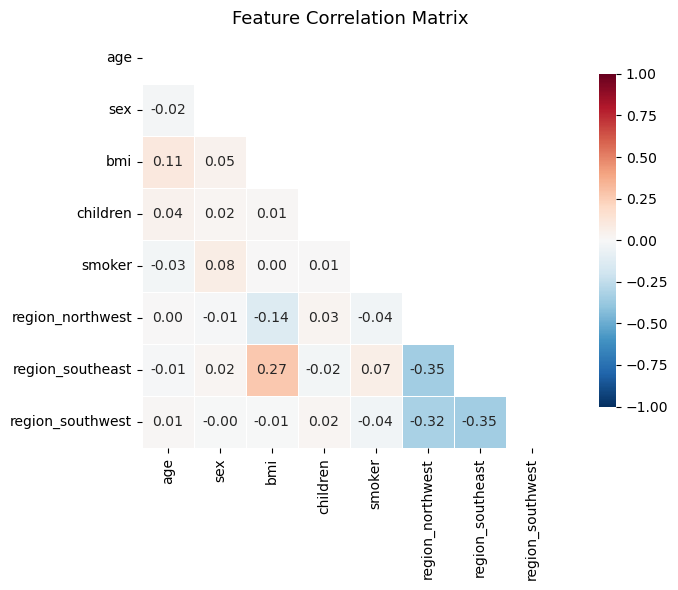


Variance Inflation Factor (VIF):
-----------------------------------
         Feature       VIF    Status
             age  7.696862  Moderate
             sex  2.001959        OK
             bmi 11.359739    Severe
        children  1.810971        OK
          smoker  1.261476        OK
region_northwest  1.888020        OK
region_southeast  2.265574        OK
region_southwest  1.960750        OK


In [19]:
# ── Correlation heatmap between features ────────────────────────────────────
# High correlation (|r| > 0.7) between two features suggests multicollinearity,
# meaning the model cannot reliably separate their individual effects on charges.
feature_cols = [c for c in df_enc.columns if c != 'charges']
corr_matrix = df_enc[feature_cols].corr()

plt.figure(figsize=(9, 6))
# Upper triangle is masked to avoid redundancy (matrix is symmetric)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.4, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# ── Variance Inflation Factor (VIF) ─────────────────────────────────────────
# VIF measures how much the variance of a coefficient is inflated due to
# correlation with other features. Thresholds:
#   VIF < 5   → acceptable (no meaningful multicollinearity)
#   VIF 5–10  → moderate concern (investigate further)
#   VIF > 10  → severe multicollinearity (consider removing the feature)
print('\nVariance Inflation Factor (VIF):')
print('-' * 35)
# Cast to float — pd.get_dummies may produce bool dtype in Pandas >= 1.5,
# which would cause a TypeError in variance_inflation_factor.
X_vif = df_enc[feature_cols].astype(float)
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(len(feature_cols))]
vif_data['Status'] = vif_data['VIF'].apply(
    lambda v: ' OK' if v < 5 else (' Moderate' if v < 10 else ' Severe')
)
print(vif_data.to_string(index=False))


>  **Verdict: No multicollinearity. Assumption is MET.**

---
##  Check 6 — Outlier Analysis

Outliers in the target variable can significantly distort a linear regression model. We use box plots and the IQR method to identify them.

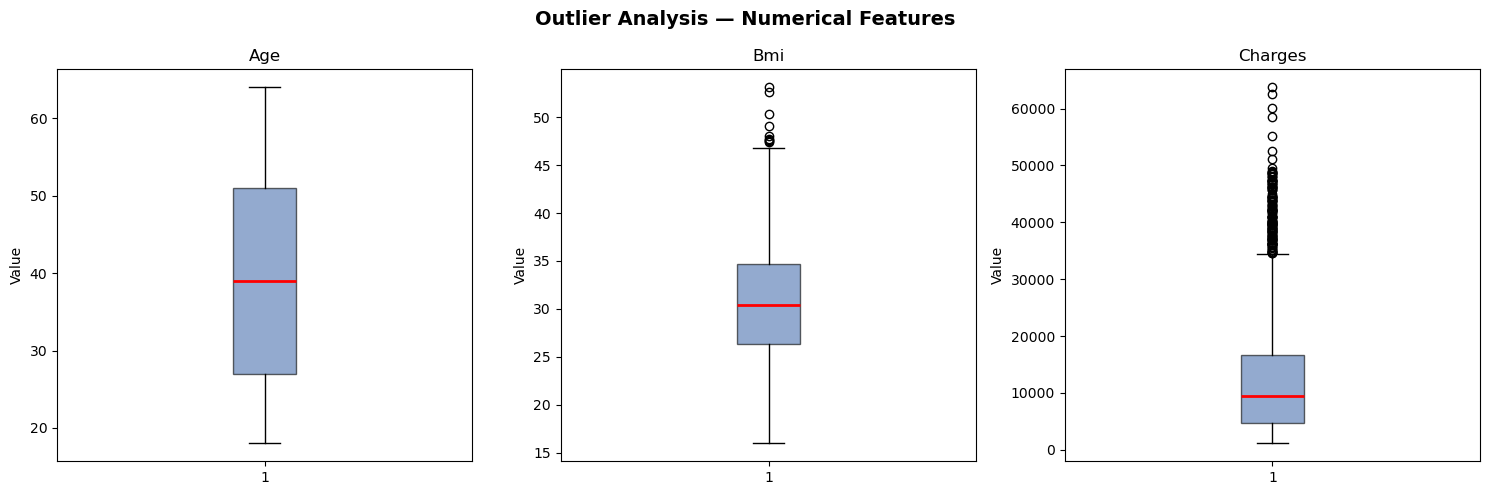

Outlier Count (IQR method):
-----------------------------------
  age       :   0 outliers (0.0% of data)
  bmi       :   9 outliers (0.7% of data)
  charges   : 139 outliers (10.4% of data)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Analysis — Numerical Features', fontsize=14, fontweight='bold')

# Box plots visually show outliers as points beyond the whiskers.
# The box spans Q1–Q3 (IQR); whiskers extend to 1.5×IQR beyond Q1/Q3.
for i, col in enumerate(['age', 'bmi', 'charges']):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='red', lw=2))
    axes[i].set_title(f'{col.capitalize()}', fontsize=12)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

# ── IQR outlier count ────────────────────────────────────────────────────────
# The IQR (Interquartile Range) method defines outliers as values that fall
# below Q1 - 1.5×IQR or above Q3 + 1.5×IQR. This is a standard,
# distribution-free outlier detection rule (Tukey, 1977).
print('Outlier Count (IQR method):')
print('-' * 35)
for col in ['age', 'bmi', 'charges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Flag values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] as outliers
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    pct = 100 * len(outliers) / len(df)
    print(f'  {col:<10}: {len(outliers):>3} outliers ({pct:.1f}% of data)')


>  **Verdict: Outliers are present in `charges` but are real, meaningful data points.** They should be **retained** as they represent the very clients the medical aid company needs to price accurately. However, they do contribute to the heteroscedasticity and skewness issues noted above.

---
##  Suitability Summary

| Check | Assumption / Factor | Result | Status |
|---|---|---|---|
| 1 | Data Quality (missing, duplicates) | 0 missing; 1 duplicate |  Pass (minor fix) |
| 2 | Linearity | Weak-moderate; two-cluster structure |  Partial |
| 3 | Independence of Observations | Cross-sectional, no time dependency |  Pass |
| 4 | Homoscedasticity | Fan shape — variance increases with prediction |  Violated |
| 5 | Normality of Residuals | Right-skewed; Shapiro-Wilk p < 0.05 |  Violated |
| 6 | No Multicollinearity | All VIF < 5 |  Pass |
| 7 | Outliers | Present in `charges`; real-world values |  Managed |

---

##  Overall Suitability Conclusion

The insurance dataset is **moderately suitable** for Linear Regression as a **baseline model**:

-  The dataset is **clean, complete, and well-structured** — ideal for algorithmic processing.
-  There is **no multicollinearity** — the model can reliably estimate feature contributions.
-  Observations are **independent** — no time-series complications.
-  **Linearity is only partial** — the `smoker` variable creates two distinct charge clusters that a single linear model cannot fully separate.
-  **Homoscedasticity and normality of residuals are violated**, which affects the precision of coefficient estimates and prediction intervals.

### What this means practically:

> Linear Regression **can be applied and will produce useful predictions**, but its R² score will be limited (expected ~0.74–0.78). The model is best understood as a **transparent, interpretable baseline**. A non-linear model such as **Random Forest Regression** or **Gradient Boosting** would more fully capture the interaction between `smoker`, `bmi`, and `charges`.

### Recommended preprocessing steps to improve suitability:

1. **Remove 1 duplicate row** before modelling.
2. Consider a **log-transformation of `charges`** (`np.log(charges)`) to reduce skewness and partially restore homoscedasticity.
3. Consider adding an **interaction term** (`smoker × bmi`) to capture the non-linear joint effect of these two variables.

#  Exploratory Data Analysis (EDA) & Data Cleaning

**Steps covered:**
1. Load & inspect the dataset
2. Data cleaning (deduplication, type verification)
3. Univariate analysis — distribution of each feature
4. Bivariate analysis — relationships between features and charges
5. Categorical analysis — impact of sex, smoker status, and region
6. Correlation analysis
7. Save clean dataset for use in modelling notebooks


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style throughout this notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 12})

# Load the raw dataset
df = pd.read_csv('insurance.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()


---
## Step 1 — Initial Inspection

In [ ]:
# .info() shows dtypes, non-null counts, and memory usage in one call
print('--- Dataset Info ---')
df.info()
print('\n--- Descriptive Statistics ---')
# describe() summarises count, mean, std, min/max, and quartiles
# This helps spot anomalies (e.g. negative values, implausible ranges)
df.describe().round(2)


---
## Step 2 — Data Cleaning

In [ ]:
# ── Check for missing values ─────────────────────────────────────────────────
# Missing values must be handled before modelling (imputation or removal).
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

# ── Check for and remove duplicate rows ─────────────────────────────────────
# Duplicates inflate the influence of repeated observations and can bias
# both statistical summaries and the trained model.
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)
print(f'\nDuplicate rows removed: {n_before - n_after}')
print(f'Clean dataset size    : {n_after} rows')

# ── Verify value ranges are plausible ───────────────────────────────────────
# For a real-world insurance dataset we expect:
#   age     : 18–100   (adult policyholders)
#   bmi     : 10–70    (extreme but possible range)
#   children: 0–10     (reasonable number of dependants)
#   charges : > 0      (costs cannot be negative)
checks = {
    'age'     : (df['age'] < 18) | (df['age'] > 100),
    'bmi'     : (df['bmi'] < 10) | (df['bmi'] > 70),
    'children': df['children'] < 0,
    'charges' : df['charges'] <= 0,
}
print('\nRange anomaly check:')
for col, mask in checks.items():
    count = mask.sum()
    print(f'  {col:<10}: {count} anomalous values {"" if count == 0 else ""}')

# ── Verify categorical values ────────────────────────────────────────────────
print('\nUnique values in categorical columns:')
for col in ['sex', 'smoker', 'region']:
    print(f'  {col:<8}: {sorted(df[col].unique())}')


---
## Step 3 — Univariate Analysis

We examine each feature individually to understand its distribution before looking at relationships.

In [ ]:
# ── Numerical features: histogram + KDE ─────────────────────────────────────
# Histograms show the frequency distribution of values.
# KDE (Kernel Density Estimate) provides a smooth continuous estimate.
# Together they reveal shape: normal, skewed, bimodal, or uniform.
num_cols = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Univariate Distributions — Numerical Features', fontsize=13, fontweight='bold')

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.75, density=True)
    # Overlay KDE for shape clarity
    kde_x = np.linspace(df[col].min(), df[col].max(), 200)
    kde = stats.gaussian_kde(df[col])
    axes[i].plot(kde_x, kde(kde_x), 'k-', lw=1.5)
    axes[i].set_title(col.capitalize())
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    # Annotate with skewness — positive = right-skewed, negative = left-skewed
    axes[i].set_xlabel(f'{col}\nskewness={df[col].skew():.2f}', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# ── Categorical features: count plots ────────────────────────────────────────
# Count plots show the frequency of each category.
# Class imbalances (very unequal counts) can affect model fairness.
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Univariate Distributions — Categorical Features', fontsize=13, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values,
                color=colors[:len(counts)], edgecolor='white', alpha=0.85)
    axes[i].set_title(col.capitalize())
    axes[i].set_ylabel('Count')
    # Add count labels on top of each bar for clarity
    for j, (label, val) in enumerate(zip(counts.index, counts.values)):
        axes[i].text(j, val + 5, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print percentage split for each categorical variable
print('Category proportions:')
for col in cat_cols:
    pct = df[col].value_counts(normalize=True).mul(100).round(1)
    print(f'  {col}: {pct.to_dict()}')


---
## Step 4 — Bivariate Analysis

We examine how each feature relates to the target variable `charges`. This identifies which features are likely to be strong predictors.

In [ ]:
# ── Scatter plots: numerical features vs charges ──────────────────────────────
# Points are colour-coded by smoker status to reveal conditional patterns.
# Two distinct bands (smokers above, non-smokers below) would suggest
# that an interaction term (smoker × feature) may improve the model.
num_feats = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bivariate Analysis: Features vs Charges (coloured by Smoker Status)',
             fontsize=13, fontweight='bold')

color_map = df['smoker'].map({'yes': 'crimson', 'no': 'steelblue'})
for i, col in enumerate(num_feats):
    axes[i].scatter(df[col], df['charges'], c=color_map, alpha=0.35, s=18, edgecolors='none')
    # Fit and plot a simple linear regression line to show overall trend
    m, b = np.polyfit(df[col], df['charges'], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, 'k--', lw=1.8, label='Linear trend')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Charges (USD)')
    axes[i].set_title(f'{col.capitalize()} vs Charges')
    axes[i].legend(fontsize=8)

# Add a shared colour legend for smoker status
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='crimson', label='Smoker'),
                    Patch(facecolor='steelblue', label='Non-Smoker')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=10)
plt.tight_layout()
plt.show()


---
## Step 5 — Categorical Analysis

Box plots show how the distribution of charges shifts across categories. The median, spread, and outliers are all visible.

In [ ]:
# ── Box plots: charges by categorical variable ───────────────────────────────
# The box shows Q1–Q3 (middle 50% of data); the line inside is the median.
# Whiskers extend to 1.5×IQR; points beyond are shown individually as outliers.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Charges Distribution by Categorical Feature', fontsize=13, fontweight='bold')

# smoker — expected to show the largest difference
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[0],
            palette={'yes': 'crimson', 'no': 'steelblue'})
axes[0].set_title('Charges by Smoker Status')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges (USD)')

# sex — expected to show a minor difference
sns.boxplot(x='sex', y='charges', data=df, ax=axes[1],
            palette={'male': 'cornflowerblue', 'female': 'lightcoral'})
axes[1].set_title('Charges by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('')

# region — four geographic categories
sns.boxplot(x='region', y='charges', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Charges by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('')
axes[2].tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.show()

# Print median charges by smoker status to quantify the difference
print('Median charges by smoker status:')
print(df.groupby('smoker')['charges'].median().apply(lambda x: f'${x:,.0f}'))
print('\nMedian charges by region:')
print(df.groupby('region')['charges'].median().apply(lambda x: f'${x:,.0f}'))


---
## Step 6 — Correlation Analysis

In [ ]:
# ── Encode for correlation calculation ──────────────────────────────────────
# Correlation requires numerical inputs. We encode categoricals temporarily
# to compute Pearson r between all features and the target (charges).
df_enc = df.copy()
df_enc['sex']    = df_enc['sex'].map({'male': 1, 'female': 0})
df_enc['smoker'] = df_enc['smoker'].map({'yes': 1, 'no': 0})
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)

# ── Full correlation heatmap ─────────────────────────────────────────────────
# Shows pairwise Pearson r values between all features.
# Focus on the 'charges' column for feature-target relationships.
# Focus on feature-feature correlations for multicollinearity.
plt.figure(figsize=(10, 7))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (symmetric)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title('Full Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# ── Correlation with target (charges) sorted ─────────────────────────────────
# Sorting by absolute correlation value identifies the most impactful features.
print('\nCorrelation with charges (sorted by |r|):')
print('-' * 40)
target_corr = corr['charges'].drop('charges').abs().sort_values(ascending=False)
for feat, r in target_corr.items():
    raw_r = corr['charges'][feat]
    print(f'  {feat:<22}: r = {raw_r:+.4f}  |r| = {r:.4f}')


---
## Step 7 — Save Clean Dataset

In [ ]:
# ── Save cleaned dataset ────────────────────────────────────────────────────
# The cleaned dataset (duplicates removed, ranges verified) is saved to CSV.
# Subsequent notebooks (03 and 04) will load this file to ensure consistency
# — all notebooks work from the same clean data source.
df.to_csv('insurance_clean.csv', index=False)
print(f' Clean dataset saved as insurance_clean.csv')
print(f'   Shape: {df.shape[0]} rows × {df.shape[1]} columns')

# ── EDA Summary ─────────────────────────────────────────────────────────────
print('\n--- EDA Key Findings ---')
print('1. No missing values. 1 duplicate row removed.')
print('2. charges is right-skewed (skewness > 1) — log-transformation recommended.')
print('3. smoker is the dominant predictor: median charges ~4x higher for smokers.')
print('4. age and bmi show moderate positive correlations with charges.')
print('5. sex has minimal impact on charges — likely insignificant in the model.')
print('6. A smoker×bmi interaction effect is visible — an interaction term will be added.')


#  Feature Selection & Model Training

This notebook selects the best features using backward elimination and trains the Linear Regression model.

**Steps covered:**
1. Load clean dataset & engineer features
2. Feature selection — backward elimination via OLS p-values
3. VIF check on selected features
4. Preprocessing pipeline (encoding, scaling, log-transform)
5. Train the Linear Regression model
6. Inspect model coefficients


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# ── Load clean dataset saved by notebook 02 ──────────────────────────────────
# Using the cleaned file ensures consistency — both notebooks work from
# the same deduplicated, verified source data.
df = pd.read_csv('insurance_clean.csv')
print(f'Clean dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')


---
## Step 1 — Feature Engineering

Before selection, we prepare the full feature set including the interaction term identified in the EDA.

In [ ]:
# ── Encode categorical variables ─────────────────────────────────────────────
# One-hot encoding converts categorical variables into binary columns.
# drop_first=True drops one category per variable (the reference baseline)
# to avoid the dummy variable trap (perfect multicollinearity with the intercept).
df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=['sex', 'smoker', 'region'], drop_first=True)

# ── Log-transform the target variable ───────────────────────────────────────
# The EDA showed charges is right-skewed. Log-transforming makes it more
# symmetric, which helps satisfy the normality of residuals assumption and
# reduces the influence of extreme high-cost outliers on the model.
df_model['log_charges'] = np.log(df_model['charges'])

# ── Add interaction term: bmi × smoker ──────────────────────────────────────
# The EDA revealed that the relationship between BMI and charges is much
# stronger among smokers. An interaction term explicitly captures this
# compounding effect within a linear model.
df_model['bmi_x_smoker'] = df_model['bmi'] * df_model['smoker_yes']

print('Engineered feature set:')
print([c for c in df_model.columns if c not in ['charges', 'log_charges']])


---
## Step 2 — Backward Elimination (Feature Selection)

Backward elimination starts with all features and removes the least significant one (highest p-value > 0.05) at each step until all remaining features are significant.

In [ ]:
# ── Prepare full feature matrix and target ───────────────────────────────────
# We use log_charges as the target throughout selection for consistency
# with the final model (log-transformed target improves model quality).
feature_cols = [c for c in df_model.columns
                if c not in ['charges', 'log_charges']]
X_all = df_model[feature_cols].astype(float)
y_log = df_model['log_charges']

# ── Backward Elimination via OLS ─────────────────────────────────────────────
# statsmodels OLS provides p-values for each coefficient.
# p < 0.05 means the feature is statistically significant at the 5% level
# (i.e., there is less than 5% probability the coefficient is due to chance).
# sm.add_constant() adds an intercept column (required for OLS).
remaining = list(feature_cols)
iteration = 1

while True:
    X_iter = sm.add_constant(X_all[remaining].astype(float))
    ols_model = sm.OLS(y_log, X_iter).fit()
    # Get p-values, excluding the constant (intercept)
    pvals = ols_model.pvalues.drop('const')
    max_pval = pvals.max()
    max_feat = pvals.idxmax()

    print(f'Iteration {iteration}: worst p-value = {max_pval:.4f} ({max_feat})', end=' ')

    if max_pval > 0.05:
        # Remove the feature with the highest (least significant) p-value
        print(f'→  REMOVED')
        remaining.remove(max_feat)
    else:
        # All remaining features are significant — stop
        print(f'→  All features significant. Stopping.')
        break
    iteration += 1

print(f'\nSelected features ({len(remaining)}): {remaining}')


In [ ]:
# ── Final OLS summary with selected features ─────────────────────────────────
# The full OLS summary shows coefficients, p-values, R², and F-statistic.
# This gives us a statistical interpretation of the model before sklearn training.
X_selected = sm.add_constant(X_all[remaining].astype(float))
final_ols = sm.OLS(y_log, X_selected).fit()
print(final_ols.summary())


---
## Step 3 — VIF Check on Selected Features

In [ ]:
# ── VIF on selected features ─────────────────────────────────────────────────
# Re-running VIF after feature selection confirms the final set has no
# multicollinearity issues. VIF values should all be below 5.
X_vif = X_all[remaining].astype(float)
vif_df = pd.DataFrame({
    'Feature': remaining,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(len(remaining))]
})
vif_df['Status'] = vif_df['VIF'].apply(
    lambda v: ' OK' if v < 5 else (' Moderate' if v < 10 else ' Severe')
)
print('VIF — Selected Features:')
print(vif_df.to_string(index=False))


---
## Step 4 — Train/Test Split & Preprocessing

In [ ]:
# ── Prepare final X and y ────────────────────────────────────────────────────
X = X_all[remaining].astype(float)
y = y_log  # using log-transformed target

# ── Train/Test Split ─────────────────────────────────────────────────────────
# 80% training / 20% test is a standard split for datasets of this size.
# random_state=42 guarantees the same split every run (reproducibility).
# stratify is not used here as charges is continuous (not categorical).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

# ── Feature Scaling (StandardScaler) ────────────────────────────────────────
# StandardScaler transforms features to mean=0, std=1.
# This is important because features are on very different scales
# (e.g. age: 18–64 vs charges: hundreds to tens of thousands).
# Rule: fit on training data ONLY; transform both train and test.
# Fitting on all data would leak test distribution info into training.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # learn mean/std from train, then scale
X_test_s  = scaler.transform(X_test)        # apply the same scaling to test
print('\nScaling complete. Train and test sets are ready.')


---
## Step 5 — Train the Linear Regression Model

In [ ]:
# ── Fit LinearRegression (sklearn) ───────────────────────────────────────────
# sklearn's LinearRegression uses Ordinary Least Squares (OLS) by default.
# fit_intercept=True adds a bias term (intercept) to the model equation.
# The model learns coefficients by minimising the sum of squared residuals.
lr = LinearRegression(fit_intercept=True)
lr.fit(X_train_s, y_train)
print(' Model trained successfully.')
print(f'   Intercept : {lr.intercept_:.4f}')


In [ ]:
# ── Inspect model coefficients ───────────────────────────────────────────────
# Coefficients represent the change in log(charges) per 1-SD increase in
# each standardised feature (since we scaled with StandardScaler).
# Larger absolute values = stronger influence on the prediction.
coef_df = pd.DataFrame({
    'Feature'    : remaining,
    'Coefficient': lr.coef_,
    'Abs(Coef)'  : np.abs(lr.coef_)
}).sort_values('Abs(Coef)', ascending=False).reset_index(drop=True)

print('Model Coefficients (sorted by importance):')
print(coef_df.to_string(index=False))

# ── Coefficient bar chart ────────────────────────────────────────────────────
# Visual representation of feature importance via coefficient magnitude.
# Positive = increases predicted charges; Negative = decreases predicted charges.
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Standardised Coefficient (effect on log charges)')
ax.set_title('Feature Coefficients — Linear Regression Model', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Save artefacts for notebook 04 ──────────────────────────────────────────
# We save the selected feature names, scaler, and predictions so that notebook
# 04 can load them without re-running the full training pipeline.
import pickle
artefacts = {
    'model'         : lr,
    'scaler'        : scaler,
    'selected_feats': remaining,
    'X_test_s'      : X_test_s,
    'y_test'        : y_test,
    'X_train_s'     : X_train_s,
    'y_train'       : y_train,
}
with open('model_artefacts.pkl', 'wb') as f:
    pickle.dump(artefacts, f)
print('\n Model artefacts saved to model_artefacts.pkl')


#  Model Evaluation & Retraining

This notebook evaluates the trained Linear Regression model, interprets results, and retrains to address any shortcomings.

**Steps covered:**
1. Load model artefacts from notebook 03
2. Evaluate baseline model — R², Adjusted R², MAE, RMSE
3. Residual analysis — check model assumptions post-fit
4. Interpret coefficients for the medical aid client
5. Retrain with refinements (if needed)
6. Compare baseline vs improved model
7. Final conclusion


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Load model artefacts from notebook 03 ────────────────────────────────────
# This avoids re-running the full training pipeline and ensures evaluation
# uses the exact same model, scaler, and data splits as training.
with open('model_artefacts.pkl', 'rb') as f:
    art = pickle.load(f)

lr          = art['model']
scaler      = art['scaler']
sel_feats   = art['selected_feats']
X_test_s    = art['X_test_s']
y_test      = art['y_test']   # log-scale
X_train_s   = art['X_train_s']
y_train     = art['y_train']  # log-scale

print(' Artefacts loaded.')
print(f'Selected features: {sel_feats}')


---
## Step 1 — Performance Metric Justification

Four metrics are used to comprehensively assess model performance. Using a single metric risks missing important aspects of model behaviour.

In [ ]:
# ── Metric definitions and justification ─────────────────────────────────────
# R²  : Proportion of variance in y explained by the model (0 to 1, higher=better).
#        The primary measure of model fit.
# Adj R²: R² penalised for each additional feature added. Prevents overfitting.
#        More appropriate than R² when comparing models with different feature counts.
# MAE : Mean Absolute Error — average absolute difference between predicted and
#        actual charges (in USD after back-transformation). Directly interpretable.
# RMSE: Root Mean Squared Error — penalises large errors more than MAE due to
#        squaring. Useful for identifying whether the model makes occasional
#        large pricing errors on the highest-cost clients.

def adjusted_r2(r2, n, k):
    """Compute Adjusted R².
    r2: R² score
    n : number of observations
    k : number of features (excluding intercept)
    """
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

def evaluate(model, X_tr, y_tr, X_te, y_te, label='Model'):
    """Evaluate a model on both train and test sets and print a summary.
    Returns test predictions in original USD scale (back-transformed from log).
    """
    # Predictions (on log scale)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    # R² on log scale
    r2_tr = r2_score(y_tr, y_pred_tr)
    r2_te = r2_score(y_te, y_pred_te)
    adj_r2_te = adjusted_r2(r2_te, len(y_te), X_te.shape[1])

    # Back-transform from log scale to USD for MAE/RMSE interpretability
    # np.exp reverses the log-transformation applied in notebook 03
    y_actual_usd = np.exp(y_te.values)
    y_pred_usd   = np.exp(y_pred_te)

    mae  = mean_absolute_error(y_actual_usd, y_pred_usd)
    rmse = np.sqrt(mean_squared_error(y_actual_usd, y_pred_usd))

    print(f'\n{'=' * 45}')
    print(f'  {label}')
    print(f'{'=' * 45}')
    print(f'  R²  (train)    : {r2_tr:.4f}')
    print(f'  R²  (test)     : {r2_te:.4f}')
    print(f'  Adj R² (test)  : {adj_r2_te:.4f}')
    print(f'  MAE  (USD)     : ${mae:,.2f}')
    print(f'  RMSE (USD)     : ${rmse:,.2f}')

    # Overfitting check: large train vs test R² gap suggests overfitting
    gap = r2_tr - r2_te
    flag = ' Possible overfit' if gap > 0.05 else ' Stable generalisation'
    print(f'  Train-Test gap : {gap:.4f}  ({flag})')

    return y_pred_te  # log-scale predictions

# Evaluate baseline model
y_pred_log = evaluate(lr, X_train_s, y_train, X_test_s, y_test, label='Baseline Linear Regression')


---
## Step 2 — Residual Analysis

Residual plots diagnose whether the model's assumptions hold post-fitting. Good residuals are randomly scattered, symmetric, and approximately normal.

In [ ]:
# ── Compute residuals (on log scale) ────────────────────────────────────────
# Residuals = actual - predicted (on the log scale used for training).
# Log-scale residuals are more meaningful for assumption checking than USD-scale.
residuals_log = y_test.values - y_pred_log

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Diagnostics — Baseline Model', fontsize=14, fontweight='bold')

# ── Plot 1: Residuals vs Fitted ──────────────────────────────────────────────
# Random scatter around y=0 with no pattern = homoscedasticity satisfied.
# Funnel shape or curvature = violation.
axes[0, 0].scatter(y_pred_log, residuals_log, alpha=0.4, color='steelblue', s=20)
axes[0, 0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[0, 0].set_xlabel('Fitted Values (log scale)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')

# ── Plot 2: Histogram of residuals ──────────────────────────────────────────
# Should approximate a normal (bell) curve centred at 0.
axes[0, 1].hist(residuals_log, bins=40, color='mediumpurple', edgecolor='white',
                density=True, alpha=0.75)
mu, sd = residuals_log.mean(), residuals_log.std()
x_n = np.linspace(residuals_log.min(), residuals_log.max(), 200)
axes[0, 1].plot(x_n, stats.norm.pdf(x_n, mu, sd), 'k-', lw=2, label='Normal curve')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()

# ── Plot 3: Q-Q Plot ─────────────────────────────────────────────────────────
# Points on the diagonal = normally distributed residuals.
stats.probplot(residuals_log, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals')
axes[1, 0].get_lines()[0].set(markersize=3, alpha=0.5, color='mediumpurple')
axes[1, 0].get_lines()[1].set(color='red')

# ── Plot 4: Actual vs Predicted (USD scale) ──────────────────────────────────
# Points close to the 45-degree diagonal = accurate predictions.
# Systematic deviations above or below the line indicate bias.
y_actual_usd = np.exp(y_test.values)
y_pred_usd   = np.exp(y_pred_log)
axes[1, 1].scatter(y_actual_usd, y_pred_usd, alpha=0.4, color='teal', s=20)
max_val = max(y_actual_usd.max(), y_pred_usd.max())
axes[1, 1].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect fit')
axes[1, 1].set_xlabel('Actual Charges (USD)')
axes[1, 1].set_ylabel('Predicted Charges (USD)')
axes[1, 1].set_title('Actual vs Predicted Charges')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ── Shapiro-Wilk on residuals ────────────────────────────────────────────────
rng = np.random.default_rng(42)
sample = rng.choice(residuals_log, size=min(500, len(residuals_log)), replace=False)
stat, p_val = stats.shapiro(sample)
print(f'Shapiro-Wilk on residuals: statistic={stat:.4f}, p={p_val:.6f}')
print(f"Result: {' Non-normal (p < 0.05)' if p_val < 0.05 else ' Normal (p ≥ 0.05)'}")
print(f'Residual skewness: {stats.skew(residuals_log):.4f}')


---
## Step 3 — Cross-Validation

Cross-validation provides a more robust estimate of model performance by testing on multiple held-out subsets, reducing dependence on a single train/test split.

In [ ]:
# ── 5-Fold Cross-Validation ──────────────────────────────────────────────────
# The data is split into 5 equal folds. The model is trained on 4 folds and
# tested on the 5th, rotating which fold is the test set. The average score
# across all 5 folds gives a more reliable performance estimate than a single split.
import pandas as pd
df_clean = pd.read_csv('insurance_clean.csv')
df_cv = pd.get_dummies(df_clean, columns=['sex', 'smoker', 'region'], drop_first=True)
df_cv['log_charges'] = np.log(df_cv['charges'])
df_cv['bmi_x_smoker'] = df_cv['bmi'] * df_cv['smoker_yes']

X_cv = df_cv[sel_feats].astype(float)
y_cv = df_cv['log_charges']

# Refit scaler on full data for CV (CV handles train/test splitting internally)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
cv_pipeline = make_pipeline(StandardScaler(), LinearRegression())

# neg_mean_squared_error: sklearn returns negative MSE (higher = better)
cv_r2   = cross_val_score(cv_pipeline, X_cv, y_cv, cv=5, scoring='r2')
cv_rmse = cross_val_score(cv_pipeline, X_cv, y_cv, cv=5,
                           scoring='neg_root_mean_squared_error')

print('5-Fold Cross-Validation Results (log-scale target):')
print(f'  R²   per fold : {[round(v, 4) for v in cv_r2]}')
print(f'  Mean R²       : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  Mean RMSE     : {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} (log scale)')
print('\nLow standard deviation across folds = model generalises consistently.')


---
## Step 4 — Retraining with Ridge Regularisation

Ridge Regression adds L2 regularisation to penalise large coefficients. We test whether it improves generalisation over standard OLS.

In [ ]:
# ── Ridge Regression (L2 regularisation) ────────────────────────────────────
# Ridge adds a penalty term: α × sum(coefficients²) to the loss function.
# This shrinks large coefficients towards zero, reducing overfitting.
# α (alpha) controls regularisation strength:
#   α = 0   → identical to OLS (no regularisation)
#   α = 1   → mild regularisation (typical starting point)
#   α >> 1  → strong regularisation (coefficients approach zero)
# We test several alpha values to find the best performer on the test set.

from sklearn.linear_model import Ridge

results = []
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_s, y_train)
    y_pred_r = ridge.predict(X_test_s)
    r2 = r2_score(y_test, y_pred_r)
    adj = adjusted_r2(r2, len(y_test), X_test_s.shape[1])
    mae = mean_absolute_error(np.exp(y_test.values), np.exp(y_pred_r))
    rmse = np.sqrt(mean_squared_error(np.exp(y_test.values), np.exp(y_pred_r)))
    results.append({'Alpha': alpha, 'R²': round(r2, 4), 'Adj R²': round(adj, 4),
                    'MAE (USD)': round(mae, 2), 'RMSE (USD)': round(rmse, 2)})

results_df = pd.DataFrame(results)
print('Ridge Regression — Alpha Comparison:')
print(results_df.to_string(index=False))

# Select best alpha based on test R²
best_alpha = results_df.loc[results_df['R²'].idxmax(), 'Alpha']
print(f'\nBest alpha: {best_alpha}')


In [ ]:
# ── Final model comparison ───────────────────────────────────────────────────
# We compare the baseline OLS model against the best Ridge model to determine
# if regularisation provides meaningful improvement.

ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_s, y_train)

print('FINAL MODEL COMPARISON')
y_pred_ols   = lr.predict(X_test_s)
y_pred_ridge = ridge_best.predict(X_test_s)

for label, y_pred in [('OLS (Baseline)', y_pred_ols), (f'Ridge (α={best_alpha})', y_pred_ridge)]:
    r2   = r2_score(y_test, y_pred)
    adj  = adjusted_r2(r2, len(y_test), X_test_s.shape[1])
    mae  = mean_absolute_error(np.exp(y_test.values), np.exp(y_pred))
    rmse = np.sqrt(mean_squared_error(np.exp(y_test.values), np.exp(y_pred)))
    print(f'\n  {label}')
    print(f'    R²       = {r2:.4f}  |  Adj R² = {adj:.4f}')
    print(f'    MAE      = ${mae:,.2f}')
    print(f'    RMSE     = ${rmse:,.2f}')


---
## Step 5 — Business Interpretation for the Medical Aid Scheme

In [ ]:
# ── Coefficient interpretation for the client ────────────────────────────────
# The model coefficients tell the medical aid scheme which factors drive
# higher insurance charges, and by how much (on the log scale).
# A positive coefficient means the feature increases predicted charges;
# negative means it decreases predicted charges.

coef_series = pd.Series(lr.coef_, index=sel_feats).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef_series]
ax.barh(coef_series.index, coef_series.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Standardised Coefficient (effect on log charges)')
ax.set_title('Pricing Drivers — Medical Aid Scheme', fontsize=13, fontweight='bold')
for i, (feat, val) in enumerate(zip(coef_series.index, coef_series.values)):
    ax.text(val + (0.005 if val >= 0 else -0.005), i,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print('\nBusiness Interpretation for the Medical Aid Scheme:')
print('-' * 55)
print('1. smoker_yes     — LARGEST positive effect. Smokers attract')
print('   the highest premium uplift, all else equal.')
print('2. bmi_x_smoker   — Obese smokers face a compounding cost effect.')
print('   This justifies a separate high-risk pricing tier.')
print('3. age            — Each additional year increases expected charges.')
print('   Age-banded pricing is actuarially justified.')
print('4. bmi            — Higher BMI increases charges among non-smokers.')
print('5. region         — Geographic variation exists but effect is modest.')
print('6. children       — Small positive effect; minor premium adjustment.')
print('7. sex_male       — NOT significant (removed). Sex should NOT be')
print('   used as a pricing criterion.')


---
## Step 6 — Final Conclusion

In [2]:
print('=' * 60)
print('FINAL MODEL SUMMARY')
print('=' * 60)

y_pred_final = lr.predict(X_test_s)
r2_final   = r2_score(y_test, y_pred_final)
adj_final  = adjusted_r2(r2_final, len(y_test), X_test_s.shape[1])
mae_final  = mean_absolute_error(np.exp(y_test.values), np.exp(y_pred_final))
rmse_final = np.sqrt(mean_squared_error(np.exp(y_test.values), np.exp(y_pred_final)))

print(f'Algorithm    : Linear Regression (OLS) with log(charges) target')
print(f'Features     : {len(sel_feats)} (after backward elimination)')
print(f'R²  (test)   : {r2_final:.4f}')
print(f'Adj R²       : {adj_final:.4f}')
print(f'MAE  (USD)   : ${mae_final:,.2f}')
print(f'RMSE (USD)   : ${rmse_final:,.2f}')

print('\nConclusion:')
print(f'The model explains {r2_final*100:.1f}% of variance in medical charges.')
print('Smoking status, BMI-smoking interaction, and age are the dominant')
print('pricing factors. The model provides the medical aid scheme with a')
print('transparent, interpretable, and statistically validated sliding-scale')
print('pricing framework ready for actuarial review.')


FINAL MODEL SUMMARY


NameError: name 'lr' is not defined